# Loan Default Prediction - Exploratory Data Analysis (EDA)

**Goal:** understand the cleaned Lending Club data before training models - how many loans default,
which borrower and loan features are linked to default, what is missing or unusual, and how the
default rate changes over time.

**Data:** `data/processed/train_clean.parquet` (made by `src/clean_data.py`) - 27,003 loans issued
June 2007 to December 2011. `loan_status = 1` means the loan defaulted.

Every chart is saved to `reports/figures/` so it can go straight into the project report.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_auc_score

# Works whether the notebook is opened from the project folder or from notebooks/
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT / "data" / "processed"
FIG = PROJECT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Chart style: one blue for single-series charts, blue vs orange for repaid vs defaulted,
# quiet grey axes and grid so the data stands out.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False,
})
pct = mtick.PercentFormatter(1.0, decimals=0)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")
    plt.show()

def default_rate_bars(ax, rates, overall, horizontal=False, labels=None, note=True):
    # Bar chart of default rate per group with the overall average as a dashed reference line.
    names = [str(x) for x in (labels if labels is not None else rates.index)]
    if horizontal:
        ax.barh(names, rates.values, color=BLUE, height=0.6)
        ax.axvline(overall, color=MUTED, ls="--", lw=1)
        ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
        for i, v in enumerate(rates.values):
            ax.text(v + 0.004, i, f"{v:.1%}", va="center", color=INK2, fontsize=9)
        if note:
            ax.text(1.0, 1.01, f"dashed line = overall {overall:.1%}", transform=ax.transAxes,
                    ha="right", va="bottom", color=MUTED, fontsize=8.5)
    else:
        ax.bar(names, rates.values, color=BLUE, width=0.6)
        ax.axhline(overall, color=MUTED, ls="--", lw=1)
        ax.yaxis.set_major_formatter(pct); ax.grid(axis="x", visible=False)
        for i, v in enumerate(rates.values):
            ax.text(i, v + 0.006, f"{v:.1%}", ha="center", color=INK2, fontsize=9)
        if note:
            ax.text(1.0, 1.01, f"dashed line = overall {overall:.1%}", transform=ax.transAxes,
                    ha="right", va="bottom", color=MUTED, fontsize=8.5)

## 1. Data overview

In [2]:
df = pd.read_parquet(DATA / "train_clean.parquet")
y = df["loan_status"]
OVERALL = y.mean()
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Loans issued: {df.issue_date.min():%b %Y} to {df.issue_date.max():%b %Y}")
print(f"Duplicate loan ids: {df.id.duplicated().sum()}")
df.head()

Rows: 27,003   Columns: 31
Loans issued: Jun 2007 to Dec 2011
Duplicate loan ids: 0


,id,loan_amnt,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec_bankruptcies,term_months,credit_history_months,sub_grade_num,ever_delinquent,loan_to_income,installment_to_income,revol_bal_to_income,issue_date,loan_status
0,540179,10000,13.23,338.05,C,C1,4.0,RENT,37000.0,Not Verified,...,0.0,36,94,11,1,0.270270,0.109638,0.276135,2010-07-01,0
1,585434,14000,7.88,437.94,A,A5,0.0,RENT,105000.0,Not Verified,...,0.0,36,62,5,0,0.133333,0.050050,0.126733,2010-09-01,0
2,457736,9475,8.94,301.04,A,A5,9.0,OWN,27000.0,Not Verified,...,0.0,36,126,5,0,0.350926,0.133796,0.291333,2009-11-01,0
3,734349,4000,7.29,124.04,A,A4,10.0,OWN,35000.0,Not Verified,...,0.0,36,160,4,0,0.114286,0.042528,0.838800,2011-04-01,0
4,1050080,3600,6.62,110.54,A,A2,1.0,RENT,60000.0,Not Verified,...,0.0,36,152,2,0,0.060000,0.022108,0.258367,2011-12-01,1


In [3]:
df.describe().T[["mean", "50%", "min", "max"]].round(2)

,mean,50%,min,max
id,676300.72566,657052.0,54734.0,1077430.0
loan_amnt,11087.94671,9750.0,500.0,35000.0
int_rate,11.921494,11.71,5.42,24.4
installment,323.375002,277.57,15.69,1302.69
emp_length,4.967457,4.0,0.0,10.0
annual_inc,68777.705736,59000.0,4000.0,6000000.0
dti,13.259037,13.35,0.0,29.99
delinq_2yrs,0.149169,0.0,0.0,11.0
inq_last_6mths,0.871088,1.0,0.0,8.0
mths_since_last_delinq,35.700354,34.0,0.0,120.0


## 2. Missing values
Only four columns still have gaps. They are filled later inside the model pipeline (using training data only),
so the test data never leaks into the fill values.

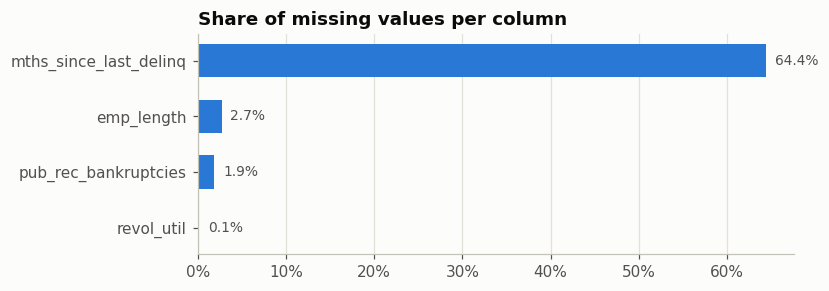

In [4]:
miss = df.isna().mean()
miss = miss[miss > 0].sort_values()
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(miss.index, miss.values, color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
for i, v in enumerate(miss.values):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center", color=INK2, fontsize=9)
ax.set_title("Share of missing values per column")
save(fig, "01_missing_values")

**Insight:** `mths_since_last_delinq` is 64% empty because most borrowers were **never** late - the gap itself is
information, which is why cleaning added the `ever_delinquent` flag. The other gaps are small (under 3%).

## 3. Target: how many loans default?

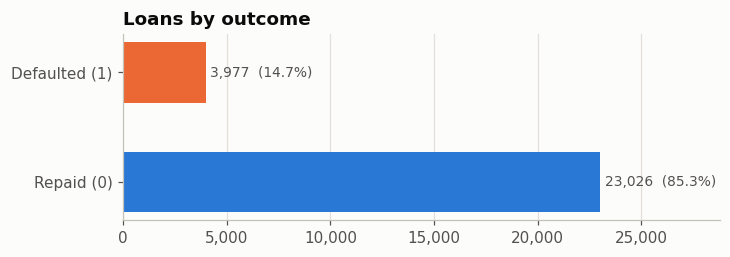

In [5]:
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(["Repaid (0)", "Defaulted (1)"], counts.values, color=[BLUE, ORANGE], height=0.55)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for i, v in enumerate(counts.values):
    ax.text(v + 200, i, f"{v:,}  ({v / len(y):.1%})", va="center", color=INK2, fontsize=9)
ax.set_xlim(0, counts.max() * 1.25)
ax.set_title("Loans by outcome")
save(fig, "02_target_balance")

**Insight:** only **14.7%** of loans default (about 1 in 7). The data is **imbalanced**, so:
- accuracy is misleading (predicting "repaid" for everyone is already 85% accurate) - we use **ROC-AUC**, precision and recall;
- models get class weights (`class_weight` / `scale_pos_weight`) or SMOTE;
- train / validation / test splits are stratified so each keeps the 14.7% rate.

## 4. Default rate by loan and borrower categories

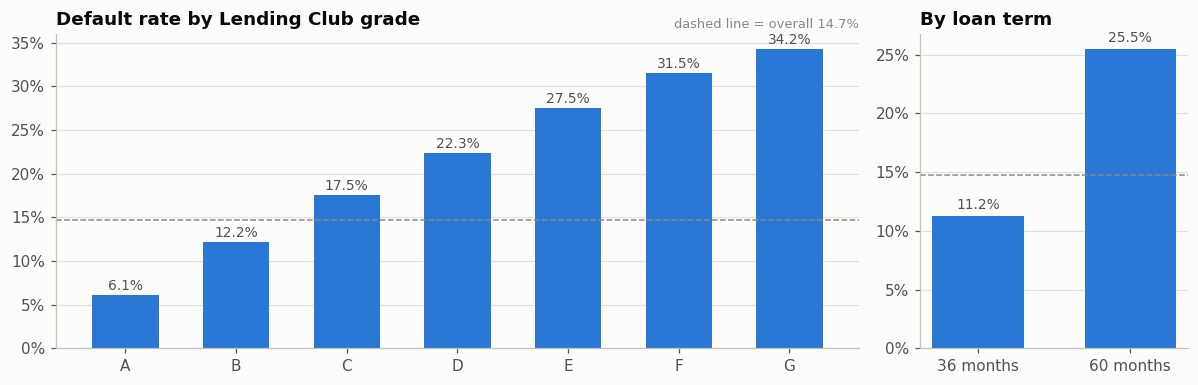

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [3, 1]})
default_rate_bars(axes[0], y.groupby(df.grade).mean(), OVERALL)
axes[0].set_title("Default rate by Lending Club grade")
default_rate_bars(axes[1], y.groupby(df.term_months).mean(), OVERALL, labels=["36 months", "60 months"], note=False)
axes[1].set_title("By loan term")
fig.tight_layout()
save(fig, "03_default_by_grade_term")

**Insight:** risk climbs steadily with grade - **6.1% for grade A to 34.2% for grade G**, more than 5x.
60-month loans default **2.3x** as often as 36-month loans (25.5% vs 11.2%). Grade and term will be among the
strongest features.

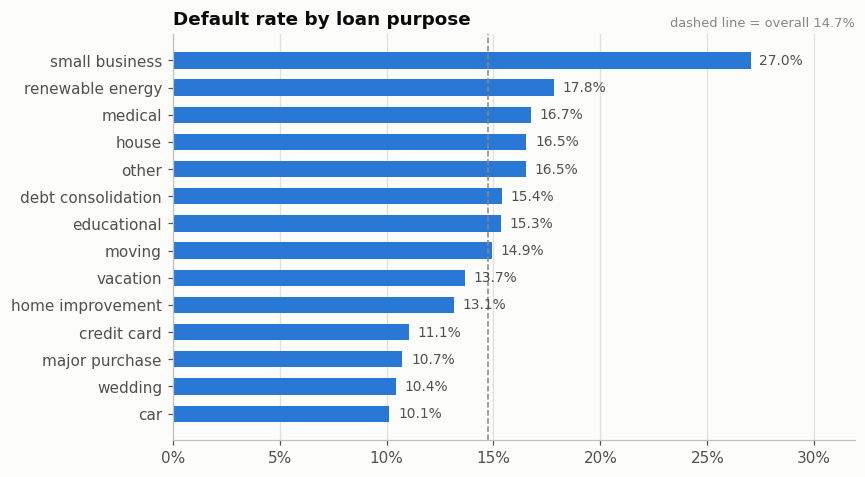

In [7]:
by_purpose = y.groupby(df.purpose).mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.8))
default_rate_bars(ax, by_purpose, OVERALL, horizontal=True,
                  labels=[p.replace("_", " ") for p in by_purpose.index])
ax.set_xlim(0, by_purpose.max() * 1.18)
ax.set_title("Default rate by loan purpose")
save(fig, "04_default_by_purpose")

**Insight:** **small business** loans are the riskiest (27.0%), almost double the average. Car, wedding and
major-purchase loans are the safest (about 10%). Debt consolidation is the most common purpose (47% of loans)
and sits close to the average.

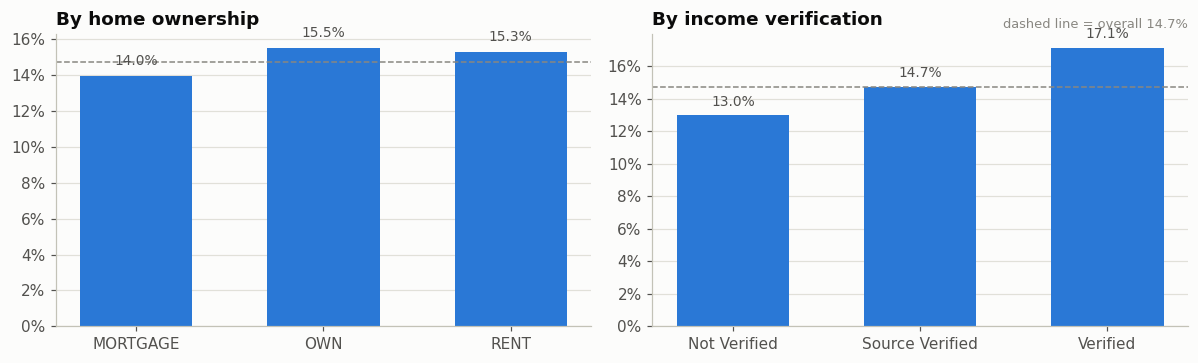

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ho = df.home_ownership.where(df.home_ownership != "OTHER")  # OTHER has only 64 loans
default_rate_bars(axes[0], y.groupby(ho).mean(), OVERALL, note=False)
axes[0].set_title("By home ownership")
default_rate_bars(axes[1], y.groupby(df.verification_status).mean(), OVERALL)
axes[1].set_title("By income verification")
fig.tight_layout()
save(fig, "05_default_by_home_verification")

**Insight:** home ownership makes little difference (14.0% to 15.5%). Surprisingly, **verified** incomes default
*more* (17.1% vs 13.0% not verified) - Lending Club verified the riskier-looking applications, so verification
is a signal of how risky the lender already thought the loan was, not a safety guarantee.

## 5. Default rate across numeric features
Each numeric feature is split into five equal-sized groups (quintiles, lowest to highest) and the default rate
is shown per group. A rising pattern means "more of this feature, more risk".

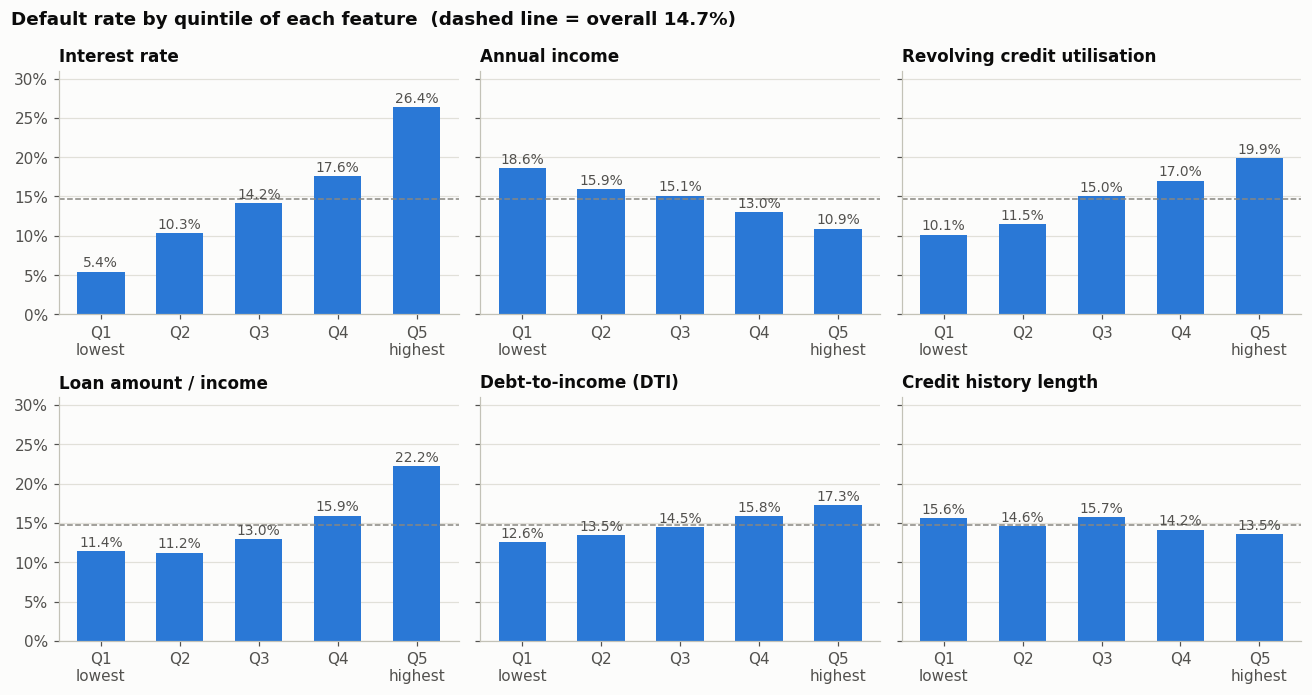

In [9]:
features = {
    "int_rate": "Interest rate", "annual_inc": "Annual income", "revol_util": "Revolving credit utilisation",
    "loan_to_income": "Loan amount / income", "dti": "Debt-to-income (DTI)", "credit_history_months": "Credit history length",
}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharey=True)
for ax, (col, title) in zip(axes.flat, features.items()):
    bins = pd.qcut(df[col], 5, duplicates="drop")
    rates = y.groupby(bins, observed=True).mean()
    default_rate_bars(ax, rates, OVERALL, labels=["Q1\nlowest", "Q2", "Q3", "Q4", "Q5\nhighest"][: len(rates)], note=False)
    ax.set_title(title, fontsize=11)
axes[0, 0].set_ylim(0, 0.31)
fig.suptitle(f"Default rate by quintile of each feature  (dashed line = overall {OVERALL:.1%})", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "06_default_by_numeric_quintiles")

**Insights:**
- **Interest rate** is the clearest signal: 5.4% default in the cheapest fifth vs 26.4% in the most expensive.
- **Higher income = lower risk:** 18.6% in the lowest income fifth vs 10.9% in the highest.
- **Revolving utilisation** (how much of the credit card limit is used) doubles risk from 10.1% to 19.9%.
- **Loan / income** (a feature we created) rises from 11.4% to 22.2% - borrowing a lot relative to income is risky.
- **DTI** rises gently (12.6% to 17.3%); **credit history length** barely matters.

## 6. Distributions: repaid vs defaulted
The shape of each feature for the two groups. The more the two curves are separated, the more useful the feature.

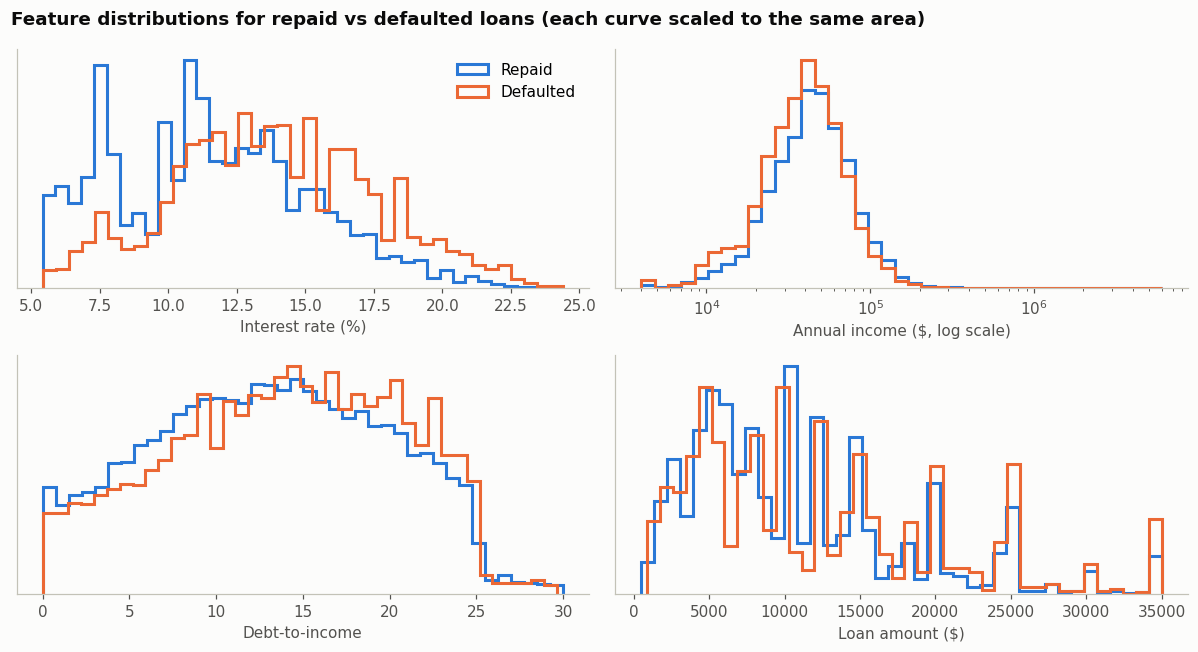

In [10]:
dist = {"int_rate": ("Interest rate (%)", False), "annual_inc": ("Annual income ($, log scale)", True),
        "dti": ("Debt-to-income", False), "loan_amnt": ("Loan amount ($)", False)}
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (col, (label, log)) in zip(axes.flat, dist.items()):
    x = df[col].dropna()
    bins = np.logspace(np.log10(x.clip(lower=1).min()), np.log10(x.max()), 40) if log else 40
    for val, color, name in [(0, BLUE, "Repaid"), (1, ORANGE, "Defaulted")]:
        ax.hist(x[y.loc[x.index] == val], bins=bins, density=True, histtype="step", lw=2, color=color, label=name)
    if log: ax.set_xscale("log")
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(False)
axes[0, 0].legend(loc="upper right")
fig.suptitle("Feature distributions for repaid vs defaulted loans (each curve scaled to the same area)",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "07_distributions_repaid_vs_default")

**Insight:** defaulted loans are shifted towards **higher interest rates** and slightly **lower incomes**; their DTI
and loan amounts are only a little higher. No single feature separates the groups cleanly, which is why a
multi-feature model is needed and why a realistic AUC is around 0.70, not 0.99.

## 7. Outliers

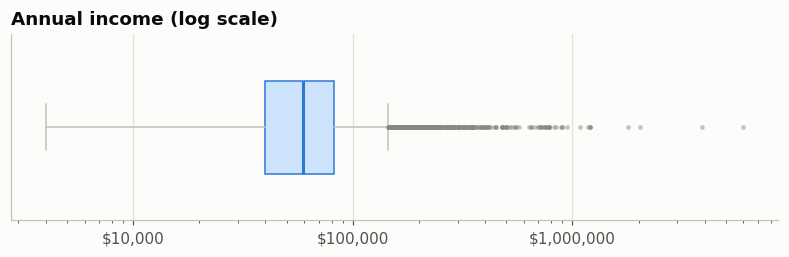

Median income: $59,000
Incomes above $1 million: 9 loans (max $6,000,000)


In [11]:
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.boxplot(df.annual_inc, vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE), medianprops=dict(color=BLUE, lw=2),
           whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS),
           flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.5))
ax.set_xscale("log"); ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title("Annual income (log scale)")
save(fig, "08_income_outliers")
print(f"Median income: ${df.annual_inc.median():,.0f}")
print(f"Incomes above $1 million: {(df.annual_inc > 1e6).sum()} loans (max ${df.annual_inc.max():,.0f})")

**Insight:** income is heavily **right-skewed** - median $59,000 but a few borrowers report up to $6 million
(9 loans above $1 million). These are kept (they may be real), but tree models handle them naturally and for
Logistic Regression we use a log transform or scaling so they don't dominate.

## 8. Correlation between numeric features

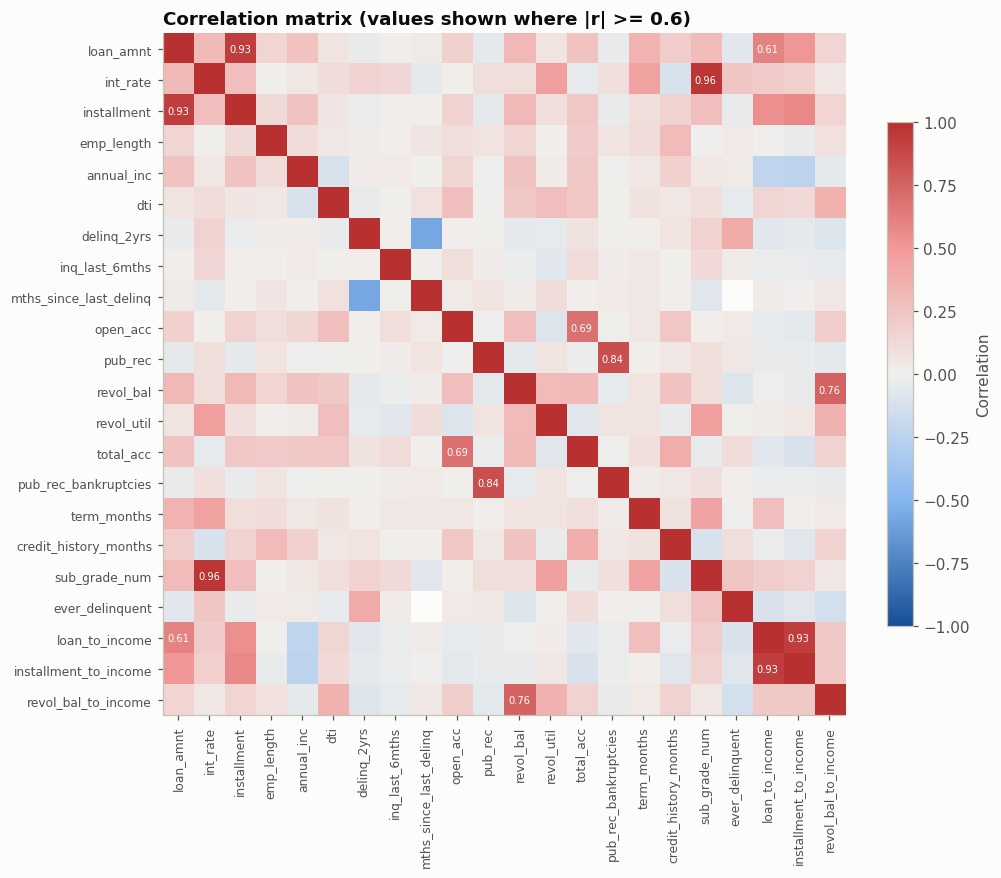

,,correlation
int_rate,sub_grade_num,0.96
loan_amnt,installment,0.93
loan_to_income,installment_to_income,0.93
pub_rec,pub_rec_bankruptcies,0.84
revol_bal,revol_bal_to_income,0.76
open_acc,total_acc,0.69
loan_amnt,loan_to_income,0.61


In [12]:
num = df.select_dtypes("number").drop(columns=["id", "loan_status"])
corr = num.corr()
cmap = LinearSegmentedColormap.from_list("div", ["#184f95", "#86b6ef", "#f0efec", "#f19a99", "#b8302f"])
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.6 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color="white")
fig.colorbar(im, ax=ax, shrink=0.7, label="Correlation")
ax.set_title("Correlation matrix (values shown where |r| >= 0.6)")
save(fig, "09_correlation_heatmap")

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs[pairs.abs() >= 0.6].sort_values(ascending=False).round(2).to_frame("correlation")

**Insight:** a few feature pairs carry almost the same information:
- `int_rate` and `sub_grade_num` (0.96) - Lending Club sets the rate from the grade;
- `loan_amnt` and `installment` (0.93), `loan_to_income` and `installment_to_income` (0.93);
- `pub_rec` and `pub_rec_bankruptcies` (0.84).

Tree models (Random Forest, XGBoost) cope with this, but for **Logistic Regression** we keep only one of each
pair (or use regularisation) so the coefficients stay stable and explainable.

## 9. Which single features separate default best?
ROC-AUC of each numeric feature on its own (0.5 = no better than a coin toss). This is a quick preview of
feature importance before any model is trained.

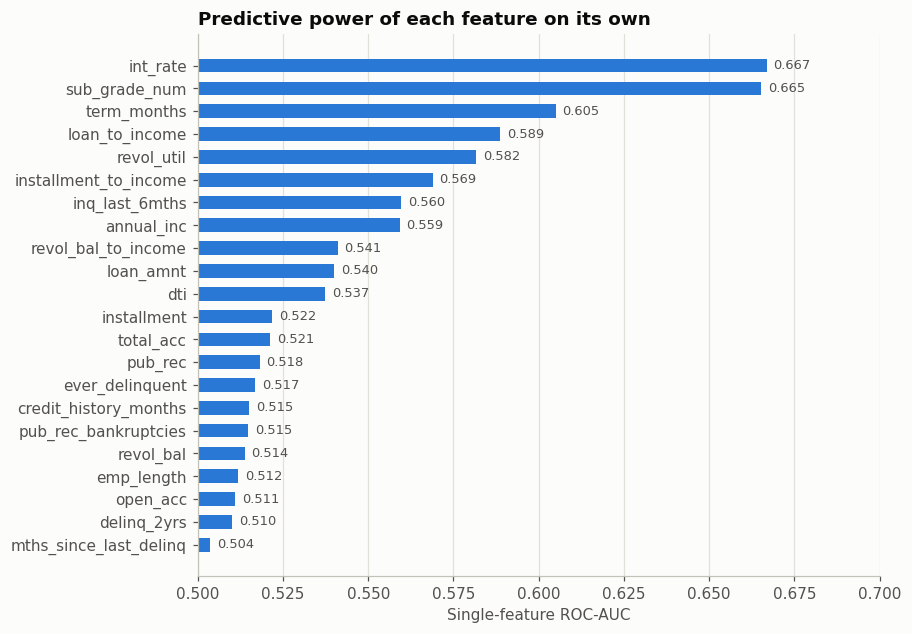

In [13]:
auc = {}
for c in num.columns:
    m = num[c].notna()
    a = roc_auc_score(y[m], num.loc[m, c])
    auc[c] = max(a, 1 - a)
auc = pd.Series(auc).sort_values()
fig, ax = plt.subplots(figsize=(8, 6.4))
ax.barh(auc.index, auc.values - 0.5, left=0.5, color=BLUE, height=0.6)
ax.axvline(0.5, color=MUTED, lw=1)
ax.set_xlim(0.5, 0.7); ax.grid(axis="y", visible=False)
for i, v in enumerate(auc.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", color=INK2, fontsize=8.5)
ax.set_xlabel("Single-feature ROC-AUC")
ax.set_title("Predictive power of each feature on its own")
save(fig, "10_single_feature_auc")

**Insight:** **interest rate (0.667)** and **sub-grade (0.665)** are the strongest single signals, followed by
**term (0.605)** and our engineered **loan-to-income (0.589)**. Many features are weak alone (0.51-0.54) but can
still help in combination. Even the best feature alone is far from the 0.85 target, which sets realistic
expectations for this dataset.

## 10. Default rate over time
Important for **drift monitoring**: if the default rate moves over time, a model trained on old loans can slowly
become wrong.

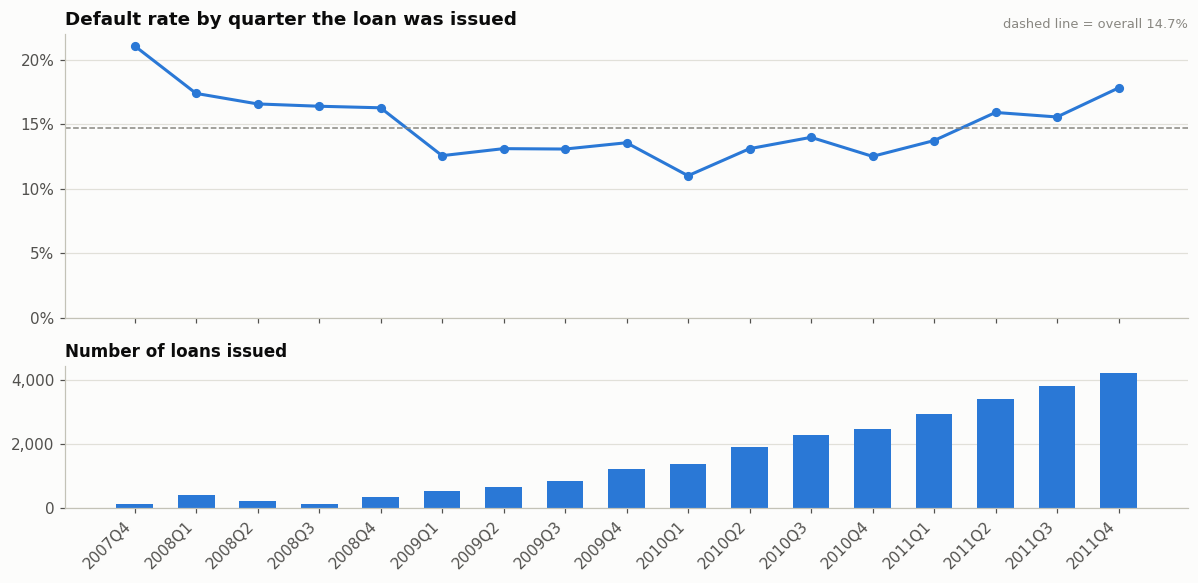

In [14]:
q = df.groupby(df.issue_date.dt.to_period("Q")).loan_status.agg(["mean", "size"])
q = q[q["size"] >= 100]  # skip 2007 quarters with too few loans to be reliable
labels = [str(p) for p in q.index]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
a1.plot(labels, q["mean"], color=BLUE, lw=2, marker="o", markersize=5)
a1.axhline(OVERALL, color=MUTED, ls="--", lw=1)
a1.text(1.0, 1.01, f"dashed line = overall {OVERALL:.1%}", transform=a1.transAxes, ha="right", va="bottom", color=MUTED, fontsize=8.5)
a1.yaxis.set_major_locator(mtick.MultipleLocator(0.05)); a1.yaxis.set_major_formatter(pct); a1.set_ylim(0, 0.22); a1.grid(axis="x", visible=False)
a1.set_title("Default rate by quarter the loan was issued")
a2.bar(labels, q["size"], color=BLUE, width=0.6)
a2.set_title("Number of loans issued", fontsize=11); a2.grid(axis="x", visible=False)
a2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.setp(a2.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
save(fig, "11_default_rate_over_time")

**Insight:** the default rate fell from about 17% (2008, financial crisis) to 11-13% in 2009-2010, then rose again
to **17.8% in Q4 2011**, while loan volume grew about 10x. The borrower mix and risk clearly shift over time -
this is exactly the **drift** our monitoring module (Evidently) is meant to catch.

## 11. Key findings (summary for the report)

| # | Finding | What we do with it |
|---|---|---|
| 1 | Only 14.7% of loans default (imbalanced) | Use ROC-AUC, class weights / SMOTE, stratified splits |
| 2 | Grade A 6.1% vs grade G 34.2% default | Grade / sub-grade are key features |
| 3 | 60-month loans default 2.3x more than 36-month | Keep `term_months` |
| 4 | Interest rate is the strongest single feature (AUC 0.667) | Keep; expect it at the top of SHAP |
| 5 | Small business loans default 27% | Keep `purpose` (one-hot encoded) |
| 6 | Higher income, lower risk; high loan-to-income, high risk | Engineered ratio features are useful |
| 7 | Income has extreme outliers (up to $6M) | Log-transform / scale for Logistic Regression |
| 8 | Several features are highly correlated (r > 0.9) | Drop duplicates for Logistic Regression |
| 9 | Default rate moves between 11% and 18% across quarters | Supports the need for drift monitoring |
| 10 | No single feature separates the classes well | Multi-feature models; realistic AUC around 0.70-0.75 |